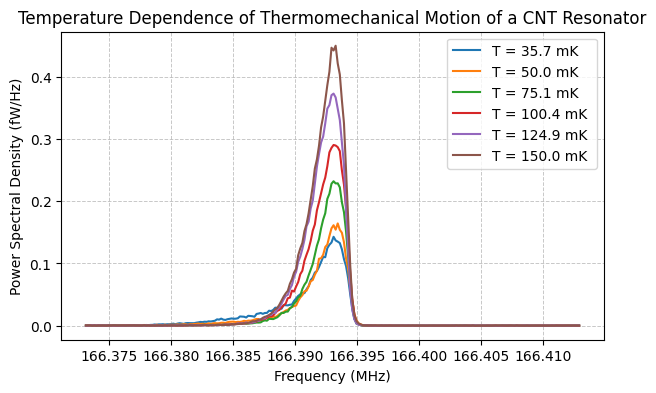

In [1]:
# grc
#HERE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd        
import qcodes as qc


run_ids = [1263, 1265, 1267, 1299, 1303, 1305, 1309, 1311, 1313, 1315,
           1319, 1321, 1323, 1325, 1329, 1331, 1333, 1335, 1339, 1341, 1343, 1345]

temperatures = [35.6766, 35.6766, 35.6766,
                50.0152, 50.0152, 50.0152,
                75.0531, 75.0531, 75.0531, 75.0531,
                100.3800, 100.3800, 100.3800, 100.3800,
                124.8840, 124.8840, 124.8840, 124.8840,
                149.9940, 149.9940, 149.9940, 149.9940]

qc.config["core"]["db_location"] = r"D:\databases CD11_D7_C1\CD11_D7_C1_part3.db"


def extract_1d(run_id,
               data_1d_name="Resistance",
               setpoint_name="single_gate",
               plot=False):
    ds       = qc.load_by_id(run_id)
    par_data = ds.get_parameter_data(data_1d_name)
    freq_raw = par_data[data_1d_name][setpoint_name]
    df_dict  = ds.to_pandas_dataframe_dict()
    psd_raw  = df_dict[data_1d_name]

    freq = np.asarray(freq_raw).flatten()
    psd  = np.asarray(psd_raw).flatten()

    if plot:
        plt.plot(freq, psd)
        plt.title(f"Measurement {run_id}")
        plt.ylabel("Avg PSD (W/Hz)")
        plt.xlabel("Frequency (MHz)")
        plt.show()

    return freq, psd


temp_data       = {}
frequency_array = None

for run_id, temp in zip(run_ids, temperatures):
    freq, psd = extract_1d(run_id,
                           data_1d_name="avg_avg_psd_nodrive",
                           setpoint_name="freq_param",
                           plot=False)

    if frequency_array is None:
        frequency_array = freq
    temp_data.setdefault(temp, []).append(psd)

plt.figure(figsize=(7, 4))

for temp in sorted(temp_data.keys()):
    traces  = np.vstack(temp_data[temp])   # shape: (n_runs, n_freq)
    avg_psd = traces.mean(axis=0)          # averaged PSD per frequency

    # Noise per temperature = minimum of averaged PSD
    noise_level = avg_psd.min()

   
    df = pd.DataFrame({
        'frequency': frequency_array,
        'psd_':      avg_psd,
        'Noise':     noise_level         
    })


    df['psd_minus_noise'] = (
        df['psd_'] + df['Noise'] - (2 * np.sqrt(df['psd_']) * np.sqrt(df['Noise']))
    )
    plt.ticklabel_format(axis='x', style='plain',useOffset=False)
    plt.ticklabel_format(axis='y', style='plain',useOffset=False)
    plt.plot(df['frequency']*1e-6, df['psd_minus_noise']*1e15,
             label=f"T = {temp:.1f} mK ")
plt.ticklabel_format(axis='x', style='plain',useOffset=False)
plt.ticklabel_format(axis='y', style='plain',useOffset=False)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power Spectral Density (fW/Hz)")
plt.title("Temperature Dependence of Thermomechanical Motion of a CNT Resonator")


plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

plt.show()


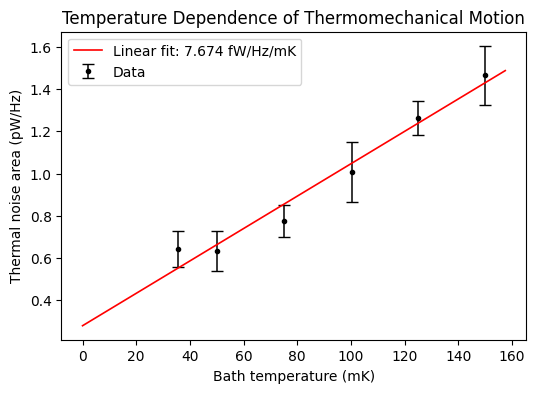

In [2]:
# thesis
temp_data       = {}
frequency_array = None

for run_id, temp in zip(run_ids, temperatures):
    freq, psd = extract_1d(run_id,
                           data_1d_name="avg_avg_psd_nodrive",
                           setpoint_name="freq_param",
                           plot=False)

    if frequency_array is None:
        frequency_array = freq
    temp_data.setdefault(temp, []).append(psd)

# Store areas for each temperature
areas = []
temps = []
area_by_temp = {}


for temp in sorted(temp_data.keys()):
    area_by_temp[temp] = []

    for psd in temp_data[temp]:

        noise_level = psd.min()

        psd_minus_noise = (
            psd + noise_level
            - 2 * np.sqrt(psd) * np.sqrt(noise_level)
        )

        area = np.trapz(psd_minus_noise, frequency_array)
        area_by_temp[temp].append(area)
temps = []
mean_areas = []
std_areas = []

for temp in sorted(area_by_temp.keys()):
    areas = np.array(area_by_temp[temp])

    temps.append(temp)
    mean_areas.append(areas.mean())
    std_areas.append(areas.std())

temps      = np.array(temps)
mean_areas = np.array(mean_areas)
std_areas  = np.array(std_areas)

# Linear fit
coeffs  = np.polyfit(temps, mean_areas * 1e12, 1)  # fit in pW/Hz
fit_line = np.poly1d(coeffs)
fit_x    = np.linspace(0, max(temps) * 1.05, 200)

plt.figure(figsize=(6, 4))
plt.errorbar(
    temps,
    mean_areas * 1e12,
    yerr=std_areas * 1e12,
    fmt="k.", markersize=6,
    capsize=4, elinewidth=1.1, alpha=1,
    label="Data",
)
plt.plot(fit_x, fit_line(fit_x), "r-", linewidth=1.2,
         label=f"Linear fit: {coeffs[0]*1e3:.3f} fW/Hz/mK")
plt.title("Temperature Dependence of Thermomechanical Motion")
plt.xlabel("Bath temperature (mK)")
plt.ylabel(r"Thermal noise area (pW/Hz)")
plt.legend()
plt.show()


    T (mK)       f0 (MHz)    Γ (kHz)    A_L (fW·kHz²)    A_D (fW·kHz)   floor (fW/Hz)
-------------------------------------------------------------------------------------
      35.7      166.39311      4.359          10.7551          0.0000          8.7276
      50.0      166.39345      3.856           9.2712          0.0000          8.9936
      75.1      166.39311      3.688          10.6176          0.0000          9.4611
     100.4      166.39311      4.023          14.5272          0.0000          9.9771
     124.9      166.39311      3.856          15.6191          0.0000         10.4655
     150.0      166.39328      3.688          16.2331          0.0000         10.9708


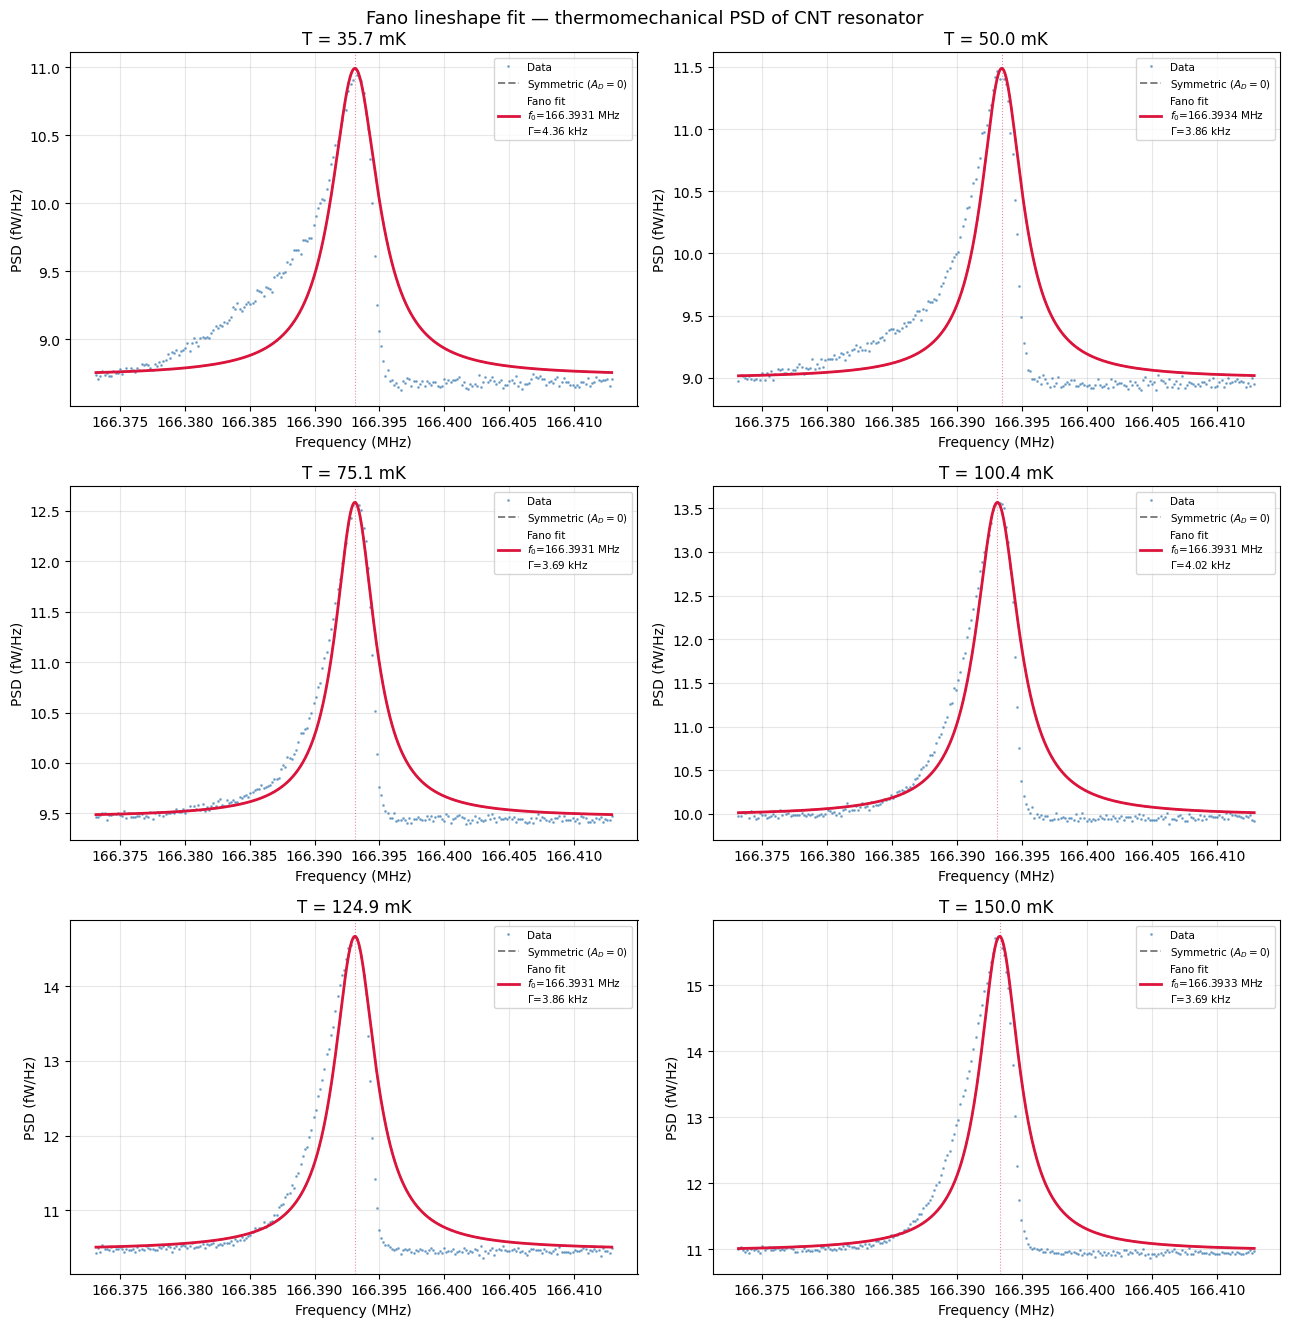

In [3]:
from scipy.optimize import curve_fit

# ---------------------------------------------------------------------------
# Fano model — internally in kHz detuning + fW/Hz for numerical stability
#
#   S(f) = S_floor + (A_L + A_D·Δf) / (Δf² + (Γ/2)²)
#
#   Δf = (f − f0) in kHz
#   A_L : fW/Hz · kHz²   (Lorentzian amplitude, > 0)
#   A_D : fW/Hz · kHz    (dispersive/Fano tilt)
#   S_floor : fW/Hz
#   Returns W/Hz for curve_fit
# ---------------------------------------------------------------------------
def fano_model(f, f0_hz, Gamma_hz, A_L, A_D, S_floor_fw):
    df  = (f - f0_hz) * 1e-3        # → kHz
    G   = Gamma_hz    * 1e-3        # → kHz
    den = df**2 + (G / 2)**2
    return (S_floor_fw + (A_L + A_D * df) / den) * 1e-15   # → W/Hz


# ---------------------------------------------------------------------------
# Fit per temperature
# ---------------------------------------------------------------------------
n_temps = len(temp_data)
ncols   = 2
nrows   = int(np.ceil(n_temps / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5 * nrows))
axes = np.array(axes).flatten()

fit_results = {}
print(f"{'T (mK)':>10}  {'f0 (MHz)':>13}  {'Γ (kHz)':>9}  "
      f"{'A_L (fW·kHz²)':>15}  {'A_D (fW·kHz)':>14}  {'floor (fW/Hz)':>14}")
print("-" * 85)

for ax_idx, temp in enumerate(sorted(temp_data.keys())):
    traces  = np.vstack(temp_data[temp])
    avg_psd = traces.mean(axis=0)          # W/Hz
    psd_fw  = avg_psd * 1e15              # fW/Hz  (O(10) → well-scaled)
    freq    = frequency_array             # Hz

    # ---- initial guesses ------------------------------------------------
    peak_idx = np.argmax(psd_fw)
    f0_guess = freq[peak_idx]

    # Floor from far edges of spectrum (avoids peak contamination)
    n_edge       = max(5, len(freq) // 8)
    S_floor_fw   = np.mean(np.concatenate([psd_fw[:n_edge], psd_fw[-n_edge:]]))
    peak_ht_fw   = max(psd_fw[peak_idx] - S_floor_fw, psd_fw[peak_idx] * 0.05)

    # Half-power linewidth
    half_max    = S_floor_fw + peak_ht_fw / 2
    above       = psd_fw > half_max
    Gamma_guess = (freq[above][-1] - freq[above][0]) if above.sum() >= 2 \
                  else (freq[-1] - freq[0]) * 0.005
    Gamma_kHz   = Gamma_guess * 1e-3

    # A_L in fW/Hz·kHz²:  at resonance S−S_floor = A_L / (Γ/2)²
    A_L_guess = peak_ht_fw * (Gamma_kHz / 2) ** 2
    A_D_guess = 0.0

    p0 = [f0_guess, Gamma_guess, A_L_guess, A_D_guess, S_floor_fw]

    # Fit only within ±12·Γ of the peak (removes irrelevant flat regions)
    window = 12 * Gamma_guess
    mask   = np.abs(freq - f0_guess) < window
    if mask.sum() < 8:
        mask = np.ones(len(freq), dtype=bool)   # fallback: use everything
    freq_w = freq[mask]
    psd_w  = avg_psd[mask]     # W/Hz

    bounds = (
        [f0_guess - window,  Gamma_guess * 0.1, 0,       -np.inf,  0               ],
        [f0_guess + window,  Gamma_guess * 20,  np.inf,   np.inf,  S_floor_fw * 3  ],
    )

    ax = axes[ax_idx]

    try:
        popt, pcov = curve_fit(
            fano_model, freq_w, psd_w,
            p0=p0, bounds=bounds, maxfev=50000,
        )
        perr = np.sqrt(np.diag(pcov))
        fit_results[temp] = {"popt": popt, "perr": perr}

        f0_fit, G_fit, AL_fit, AD_fit, Sf_fit = popt

        f_fine    = np.linspace(freq[0], freq[-1], 5000)
        fit_curve = fano_model(f_fine, *popt) * 1e15
        fit_sym   = fano_model(f_fine, f0_fit, G_fit, AL_fit, 0.0, Sf_fit) * 1e15

        ax.plot(freq * 1e-6, psd_fw, '.', ms=2, color='steelblue',
                alpha=0.6, label='Data')
        ax.plot(f_fine * 1e-6, fit_sym,   '--', lw=1.4, color='gray',
                label='Symmetric ($A_D=0$)')
        ax.plot(f_fine * 1e-6, fit_curve, '-',  lw=2.0, color='crimson',
                label=(f'Fano fit\n'
                       f'$f_0$={f0_fit*1e-6:.4f} MHz\n'
                       f'$\\Gamma$={G_fit*1e-3:.2f} kHz'))
        ax.axvline(f0_fit * 1e-6, color='crimson', ls=':', lw=0.8, alpha=0.5)

        print(f"{temp:>10.1f}  {f0_fit*1e-6:>13.5f}  {G_fit*1e-3:>9.3f}  "
              f"{AL_fit:>15.4f}  {AD_fit:>14.4f}  {Sf_fit:>14.4f}")

    except RuntimeError as exc:
        ax.text(0.5, 0.5, f'Fit failed:\n{exc}', transform=ax.transAxes,
                ha='center', va='center', fontsize=8)
        print(f"{temp:>10.1f}  -- fit failed: {exc}")

    ax.set_xlabel('Frequency (MHz)')
    ax.set_ylabel('PSD (fW/Hz)')
    ax.set_title(f'T = {temp:.1f} mK')
    ax.legend(fontsize=7.5, loc='upper right')
    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
    ax.grid(alpha=0.3)

for ax in axes[n_temps:]:
    ax.set_visible(False)

fig.suptitle('Fano lineshape fit — thermomechanical PSD of CNT resonator', fontsize=13)
fig.tight_layout()
plt.show()
